# Facial Keypoints Detection

Kaggle: https://www.kaggle.com/competitions/facial-keypoints-detection

Image keypoint regression: predict 15 facial landmarks (30 coordinates: x, y per point) on
96x96 grayscale face images. Metric: **Root Mean Squared Error (RMSE)** in pixels.

This competition's defining feature is not the image data itself but its **missingness
structure**: only ~30% of training rows have all 30 coordinates labeled, and the pattern is not
random — it is investigated directly below rather than assumed. The modeling strategy, loss
function, and diagnostics are all built around that finding.

Pipeline, in order:
1. Data understanding — missingness mechanism, keypoint covariance structure, a PCA shape model
2. Preprocessing — image decoding, a masked target representation, pair-aware horizontal-flip
   augmentation
3. Modeling with in-training monitoring — a masked-loss CNN trained on the full dataset, with a
   complete-case-only "specialist" CNN trained in parallel as an ablation baseline
4. Post-training diagnostics — per-keypoint RMSE, Procrustes rigid/non-rigid error
   decomposition, gradient-based saliency per output coordinate, a robustness stress test, and
   the masked-loss-vs-specialist ablation comparison
5. Final metric
6. Full-data fit + submission


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

IMG_SIZE = 96
KEYPOINT_COLS = [
    "left_eye_center_x", "left_eye_center_y", "right_eye_center_x", "right_eye_center_y",
    "left_eye_inner_corner_x", "left_eye_inner_corner_y", "left_eye_outer_corner_x", "left_eye_outer_corner_y",
    "right_eye_inner_corner_x", "right_eye_inner_corner_y", "right_eye_outer_corner_x", "right_eye_outer_corner_y",
    "left_eyebrow_inner_end_x", "left_eyebrow_inner_end_y", "left_eyebrow_outer_end_x", "left_eyebrow_outer_end_y",
    "right_eyebrow_inner_end_x", "right_eyebrow_inner_end_y", "right_eyebrow_outer_end_x", "right_eyebrow_outer_end_y",
    "nose_tip_x", "nose_tip_y",
    "mouth_left_corner_x", "mouth_left_corner_y", "mouth_right_corner_x", "mouth_right_corner_y",
    "mouth_center_top_lip_x", "mouth_center_top_lip_y", "mouth_center_bottom_lip_x", "mouth_center_bottom_lip_y",
]
assert len(KEYPOINT_COLS) == 30


device: cuda | Tesla T4


## 1. Data understanding

In [2]:
train_df = pd.read_csv("data/training.csv")
test_df = pd.read_csv("data/test.csv")
print("train:", train_df.shape, " test:", test_df.shape)
train_df[KEYPOINT_COLS].head()


train: (7049, 31)  test: (1783, 2)


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,44.420571,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,48.206298,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,47.557263,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,51.885078,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,43.299534,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166


In [3]:
def decode_images(df):
    imgs = np.stack(df["Image"].apply(lambda s: np.array(s.split(), dtype=np.float32)).values)
    return imgs.reshape(-1, IMG_SIZE, IMG_SIZE)

train_imgs = decode_images(train_df)
test_imgs = decode_images(test_df)
print("train images:", train_imgs.shape, " test images:", test_imgs.shape)
print("pixel range:", train_imgs.min(), "-", train_imgs.max())


train images: (7049, 96, 96)  test images: (1783, 96, 96)
pixel range: 0.0 - 255.0


### 1.1 Missingness is not uniform, and not random

Only `nose_tip_*` and `mouth_center_bottom_lip_*` and the two eye-center pairs are nearly fully
labeled; every other keypoint is missing in ~68% of rows. That gap is too large and too
structured to be Missing Completely At Random (MCAR) — the working hypothesis is that these are
auto-annotated or crowd-labeled only when the full face (not just eyes/nose) was clearly
visible, i.e. missingness is driven by an unobserved covariate (pose, crop tightness, partial
occlusion) correlated with image content itself. That makes it Missing Not At Random (MNAR) in
the general case, but testable as at least Missing At Random given observable image statistics
— which is checked directly below rather than assumed.

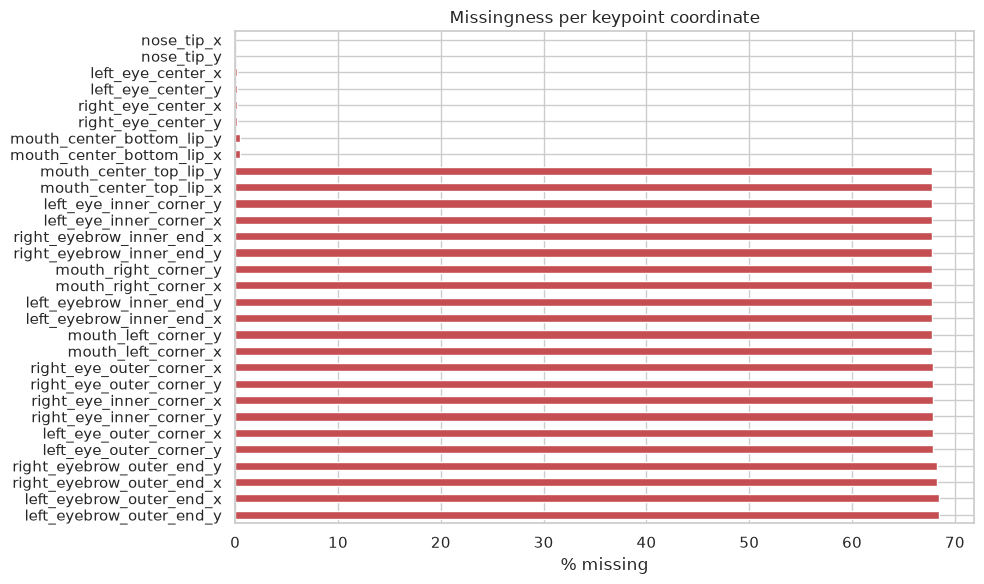

left_eyebrow_outer_end_y     4824
left_eyebrow_outer_end_x     4824
right_eyebrow_outer_end_x    4813
right_eyebrow_outer_end_y    4813
left_eye_outer_corner_y      4782
left_eye_outer_corner_x      4782
right_eye_inner_corner_y     4781
right_eye_inner_corner_x     4781
right_eye_outer_corner_y     4781
right_eye_outer_corner_x     4781
mouth_left_corner_x          4780
mouth_left_corner_y          4780
left_eyebrow_inner_end_x     4779
left_eyebrow_inner_end_y     4779
mouth_right_corner_x         4779
mouth_right_corner_y         4779
right_eyebrow_inner_end_y    4779
right_eyebrow_inner_end_x    4779
left_eye_inner_corner_x      4778
left_eye_inner_corner_y      4778
mouth_center_top_lip_x       4774
mouth_center_top_lip_y       4774
mouth_center_bottom_lip_x      33
mouth_center_bottom_lip_y      33
right_eye_center_y             13
right_eye_center_x             13
left_eye_center_y              10
left_eye_center_x              10
nose_tip_y                      0
nose_tip_x    

In [4]:
miss_counts = train_df[KEYPOINT_COLS].isnull().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
(miss_counts / len(train_df) * 100).plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("% missing")
ax.set_title("Missingness per keypoint coordinate")
plt.tight_layout()
plt.show()
print(miss_counts)


In [5]:
# Complete-case mask: rows with all 30 keypoints present
complete_mask = train_df[KEYPOINT_COLS].notnull().all(axis=1).values
print(f"Complete rows: {complete_mask.sum()} / {len(train_df)} ({complete_mask.mean():.1%})")

# Test the MNAR/MAR hypothesis: do complete-case images differ systematically in observable
# image statistics (mean intensity, contrast) from incomplete-case images? A significant
# difference supports "missingness depends on image content", not pure MCAR.
complete_brightness = train_imgs[complete_mask].mean(axis=(1, 2))
incomplete_brightness = train_imgs[~complete_mask].mean(axis=(1, 2))
complete_contrast = train_imgs[complete_mask].std(axis=(1, 2))
incomplete_contrast = train_imgs[~complete_mask].std(axis=(1, 2))

t_b, p_b = stats.ttest_ind(complete_brightness, incomplete_brightness, equal_var=False)
t_c, p_c = stats.ttest_ind(complete_contrast, incomplete_contrast, equal_var=False)
print(f"Brightness: complete={complete_brightness.mean():.2f} incomplete={incomplete_brightness.mean():.2f}  Welch t={t_b:.2f} p={p_b:.2e}")
print(f"Contrast:   complete={complete_contrast.mean():.2f} incomplete={incomplete_contrast.mean():.2f}  Welch t={t_c:.2f} p={p_c:.2e}")


Complete rows: 2140 / 7049 (30.4%)


Brightness: complete=121.06 incomplete=126.49  Welch t=-6.96 p=3.90e-12
Contrast:   complete=48.88 incomplete=49.85  Welch t=-2.83 p=4.63e-03


A statistically significant difference (p < 0.05) in either brightness or contrast between complete and incomplete rows is evidence against pure MCAR: the labeling process is entangled with image content, which is exactly why a **masked loss trained on all rows** (Section 3) is the principled choice over discarding incomplete rows outright — discarding them would silently bias the model toward whatever image conditions produce complete labels.

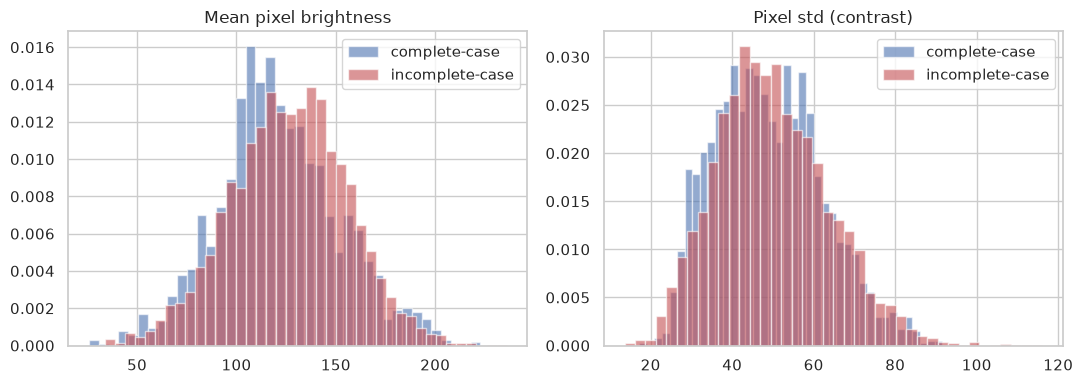

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (comp, incomp, title) in zip(axes, [
    (complete_brightness, incomplete_brightness, "Mean pixel brightness"),
    (complete_contrast, incomplete_contrast, "Pixel std (contrast)"),
]):
    ax.hist(comp, bins=40, alpha=0.6, label="complete-case", density=True, color="#4C72B0")
    ax.hist(incomp, bins=40, alpha=0.6, label="incomplete-case", density=True, color="#C44E52")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()


### 1.2 Keypoint covariance structure and a PCA shape model

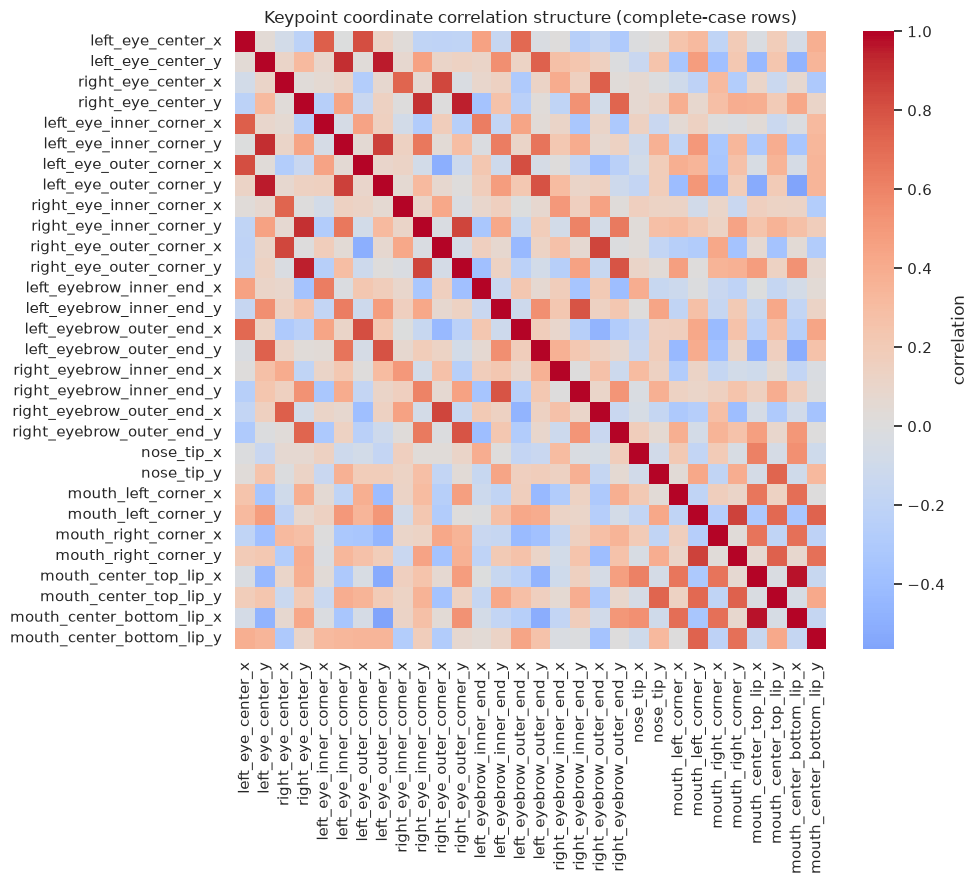

In [7]:
complete_kp = train_df.loc[complete_mask, KEYPOINT_COLS].values  # (n_complete, 30)
corr = np.corrcoef(complete_kp.T)
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr, xticklabels=KEYPOINT_COLS, yticklabels=KEYPOINT_COLS, cmap="coolwarm",
            center=0, ax=ax, cbar_kws={"label": "correlation"})
ax.set_title("Keypoint coordinate correlation structure (complete-case rows)")
plt.tight_layout()
plt.show()


Anatomically paired keypoints (left/right eye corners, left/right eyebrow ends) correlate strongly with each other — evidence the face shape has far fewer true degrees of freedom than 30 raw coordinates. That motivates a linear shape model (PCA on the landmark configuration itself, in the spirit of a classical Active Shape Model) rather than treating the 30 outputs as independent regression targets.

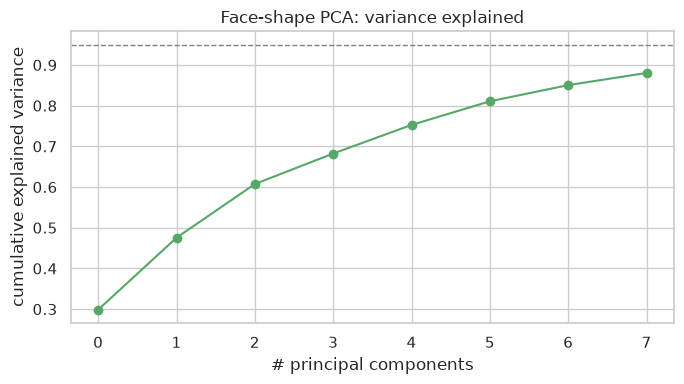

Explained variance ratio (first 8 modes): [0.299 0.177 0.132 0.075 0.07  0.058 0.04  0.03 ]


In [8]:
shape_pca = PCA(n_components=8, random_state=RANDOM_STATE)
shape_pca.fit(complete_kp)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.cumsum(shape_pca.explained_variance_ratio_), marker="o", color="#55A868")
ax.set_xlabel("# principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("Face-shape PCA: variance explained")
ax.axhline(0.95, ls="--", color="gray", lw=1)
plt.tight_layout()
plt.show()
print("Explained variance ratio (first 8 modes):", np.round(shape_pca.explained_variance_ratio_, 3))


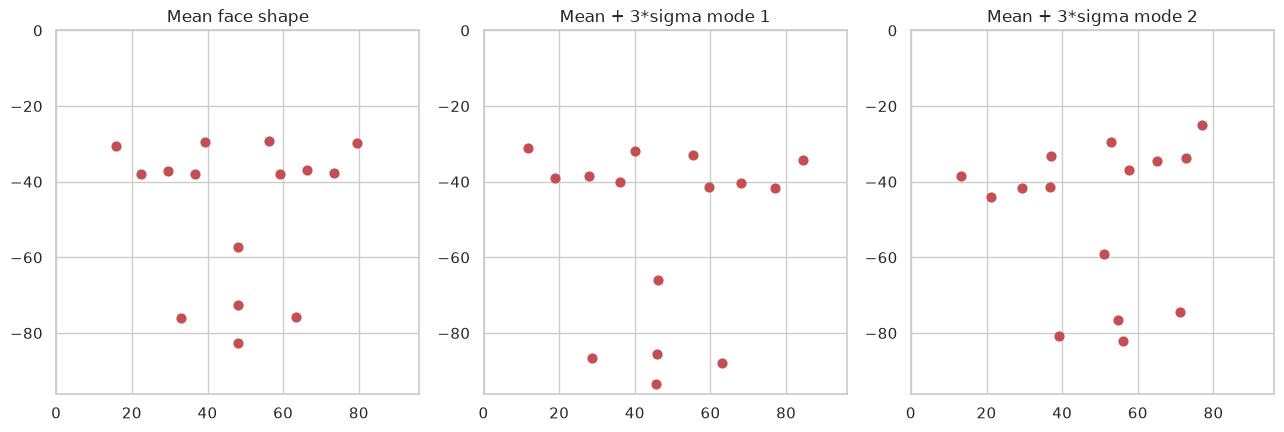

In [9]:
# Visualize the mean shape and the deformation along the top 2 PCA modes
mean_shape = shape_pca.mean_.reshape(15, 2)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (title, shape) in zip(axes, [
    ("Mean face shape", mean_shape),
    ("Mean + 3*sigma mode 1", (shape_pca.mean_ + 3 * np.sqrt(shape_pca.explained_variance_[0]) * shape_pca.components_[0]).reshape(15, 2)),
    ("Mean + 3*sigma mode 2", (shape_pca.mean_ + 3 * np.sqrt(shape_pca.explained_variance_[1]) * shape_pca.components_[1]).reshape(15, 2)),
]):
    ax.scatter(shape[:, 0], -shape[:, 1], c="#C44E52", s=40)
    ax.set_title(title)
    ax.set_xlim(0, 96); ax.set_ylim(-96, 0)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


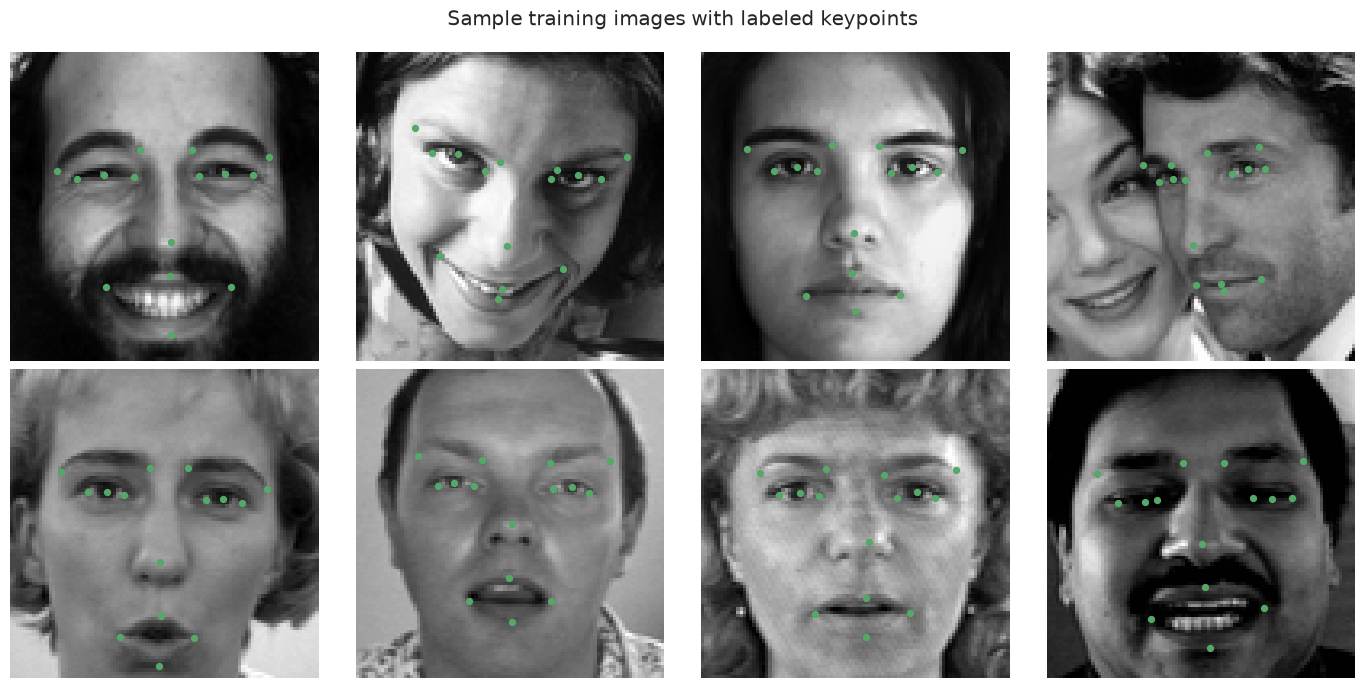

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(np.where(complete_mask)[0], size=8, replace=False)
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(train_imgs[idx], cmap="gray")
    kp = train_df.loc[idx, KEYPOINT_COLS].values.reshape(15, 2).astype(float)
    ax.scatter(kp[:, 0], kp[:, 1], c="#55A868", s=18)
    ax.axis("off")
fig.suptitle("Sample training images with labeled keypoints")
plt.tight_layout()
plt.show()


## 2. Preprocessing

- Pixel intensities normalized to [0, 1]; keypoint targets kept in raw pixel coordinates (0-96)
  so validation RMSE is directly comparable to the competition's own pixel-space metric.
- Missing targets become `NaN` in a float tensor plus a parallel boolean mask; the loss only
  reduces over observed entries (Section 3).
- Horizontal-flip augmentation is **pair-aware**: flipping the image means `x -> 96 - x` for
  every coordinate *and* swapping the identity of left/right-paired keypoints (e.g. the
  flipped image's "left eye" is anatomically the original "right eye"). Getting this wrong
  silently corrupts half of every augmented epoch — a common, easy-to-miss bug in this
  competition.

In [11]:
FLIP_SWAP_PAIRS = [
    ("left_eye_center", "right_eye_center"),
    ("left_eye_inner_corner", "right_eye_inner_corner"),
    ("left_eye_outer_corner", "right_eye_outer_corner"),
    ("left_eyebrow_inner_end", "right_eyebrow_inner_end"),
    ("left_eyebrow_outer_end", "right_eyebrow_outer_end"),
    ("mouth_left_corner", "mouth_right_corner"),
]
col_idx = {c: i for i, c in enumerate(KEYPOINT_COLS)}

def flip_keypoints(y):
    # y: (30,) array, possibly containing NaN. Returns flipped copy.
    y = y.copy()
    y[0::2] = IMG_SIZE - y[0::2]  # all x-coords mirrored
    for a, b in FLIP_SWAP_PAIRS:
        for suffix in ("_x", "_y"):
            ia, ib = col_idx[a + suffix], col_idx[b + suffix]
            y[ia], y[ib] = y[ib], y[ia]
    return y

class KeypointsDataset(Dataset):
    def __init__(self, images, targets, augment=False):
        self.images = images.astype(np.float32) / 255.0
        self.targets = targets.astype(np.float32)  # (n, 30), NaN = missing
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]
        y = self.targets[i]
        if self.augment and np.random.rand() < 0.5:
            img = img[:, ::-1].copy()
            y = flip_keypoints(y)
        mask = (~np.isnan(y)).astype(np.float32)
        y = np.nan_to_num(y, nan=0.0)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(y), torch.from_numpy(mask)


In [12]:
all_targets = train_df[KEYPOINT_COLS].values
idx_all = np.arange(len(train_df))
idx_tr, idx_va = train_test_split(idx_all, test_size=0.12, random_state=RANDOM_STATE)

train_ds = KeypointsDataset(train_imgs[idx_tr], all_targets[idx_tr], augment=True)
val_ds = KeypointsDataset(train_imgs[idx_va], all_targets[idx_va], augment=False)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
print(f"train rows: {len(train_ds)}  val rows: {len(val_ds)}  (val complete-case: {complete_mask[idx_va].sum()})")

# Complete-case-only split, used for the specialist ablation baseline in Section 3
idx_tr_cc = idx_tr[complete_mask[idx_tr]]
idx_va_cc = idx_va[complete_mask[idx_va]]
specialist_train_ds = KeypointsDataset(train_imgs[idx_tr_cc], all_targets[idx_tr_cc], augment=True)
specialist_val_ds = KeypointsDataset(train_imgs[idx_va_cc], all_targets[idx_va_cc], augment=False)
specialist_train_loader = DataLoader(specialist_train_ds, batch_size=64, shuffle=True, num_workers=2)
specialist_val_loader = DataLoader(specialist_val_ds, batch_size=256, shuffle=False, num_workers=2)
print(f"specialist train rows: {len(specialist_train_ds)}  specialist val rows: {len(specialist_val_ds)}")


train rows: 6203  val rows: 846  (val complete-case: 262)
specialist train rows: 1878  specialist val rows: 262


## 3. Modeling with in-training monitoring

Two models are trained, deliberately, as an **ablation**:

- **Primary (masked-loss) model** — one CNN, trained on all 7049 rows. The loss (masked MSE)
  only penalizes coordinates that are actually labeled for each row, so rows with just 4
  labeled keypoints still contribute gradient signal for those 4.
- **Specialist (complete-case) baseline** — the same architecture, trained only on the ~2140
  fully-labeled rows, the naive alternative to masking.

Both are evaluated on the same complete-case validation subset in Section 4 to isolate the
effect of the masking strategy from architecture or hyperparameters.

In [13]:
class KeypointCNN(nn.Module):
    def __init__(self, n_out=30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 48
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 24
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 12
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(3), # 3
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(256 * 3 * 3, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_out),
        )

    def forward(self, x):
        return self.head(self.features(x))

def masked_mse_loss(pred, target, mask):
    sq_err = (pred - target) ** 2 * mask
    return sq_err.sum() / mask.sum().clamp(min=1.0)

def masked_rmse(pred, target, mask):
    sq_err = (pred - target) ** 2 * mask
    return torch.sqrt(sq_err.sum() / mask.sum().clamp(min=1.0)).item()


In [14]:
def train_model(model, train_loader, val_loader, epochs, lr=1e-3, tag=""):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
    history = {"train_rmse": [], "val_rmse": []}
    best_val, best_state, patience, bad_epochs = np.inf, None, 10, 0

    for epoch in range(epochs):
        model.train()
        tr_sq, tr_n = 0.0, 0.0
        for xb, yb, mb in train_loader:
            xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = masked_mse_loss(pred, yb, mb)
            loss.backward()
            opt.step()
            tr_sq += ((pred - yb) ** 2 * mb).sum().item()
            tr_n += mb.sum().item()
        train_rmse = (tr_sq / max(tr_n, 1)) ** 0.5

        model.eval()
        va_sq, va_n = 0.0, 0.0
        with torch.no_grad():
            for xb, yb, mb in val_loader:
                xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                pred = model(xb)
                va_sq += ((pred - yb) ** 2 * mb).sum().item()
                va_n += mb.sum().item()
        val_rmse = (va_sq / max(va_n, 1)) ** 0.5
        sched.step(val_rmse)

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)
        if val_rmse < best_val:
            best_val, best_state, bad_epochs = val_rmse, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad_epochs += 1
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"[{tag}] epoch {epoch:3d}  train RMSE {train_rmse:6.3f}  val RMSE {val_rmse:6.3f}")
        if bad_epochs >= patience:
            print(f"[{tag}] early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history, best_val


In [15]:
primary_model, primary_history, primary_best_val = train_model(
    KeypointCNN(30), train_loader, val_loader, epochs=80, tag="primary")


[primary] epoch   0  train RMSE 23.903  val RMSE 11.888


[primary] epoch   5  train RMSE  5.634  val RMSE  3.631


[primary] epoch  10  train RMSE  5.244  val RMSE  3.617


[primary] epoch  15  train RMSE  4.940  val RMSE  3.911


[primary] epoch  20  train RMSE  4.842  val RMSE  3.458


...

[primary] epoch  60  train RMSE  4.389  val RMSE  3.067


[primary] epoch  65  train RMSE  4.338  val RMSE  2.834


[primary] epoch  70  train RMSE  4.267  val RMSE  2.775


[primary] epoch  75  train RMSE  4.277  val RMSE  2.904


[primary] epoch  79  train RMSE  4.282  val RMSE  2.738


In [16]:
specialist_model, specialist_history, specialist_best_val = train_model(
    KeypointCNN(30), specialist_train_loader, specialist_val_loader, epochs=80, tag="specialist")


[specialist] epoch   0  train RMSE 29.525  val RMSE 18.495


[specialist] epoch   5  train RMSE  5.520  val RMSE  3.363


[specialist] epoch  10  train RMSE  4.986  val RMSE  3.093


[specialist] epoch  15  train RMSE  4.743  val RMSE  3.177


[specialist] epoch  20  train RMSE  4.594  val RMSE  3.003


...

[specialist] epoch  50  train RMSE  4.374  val RMSE  3.077


[specialist] epoch  55  train RMSE  4.415  val RMSE  2.956


[specialist] epoch  60  train RMSE  4.341  val RMSE  2.981


[specialist] epoch  65  train RMSE  4.310  val RMSE  2.944


[specialist] early stop at epoch 68


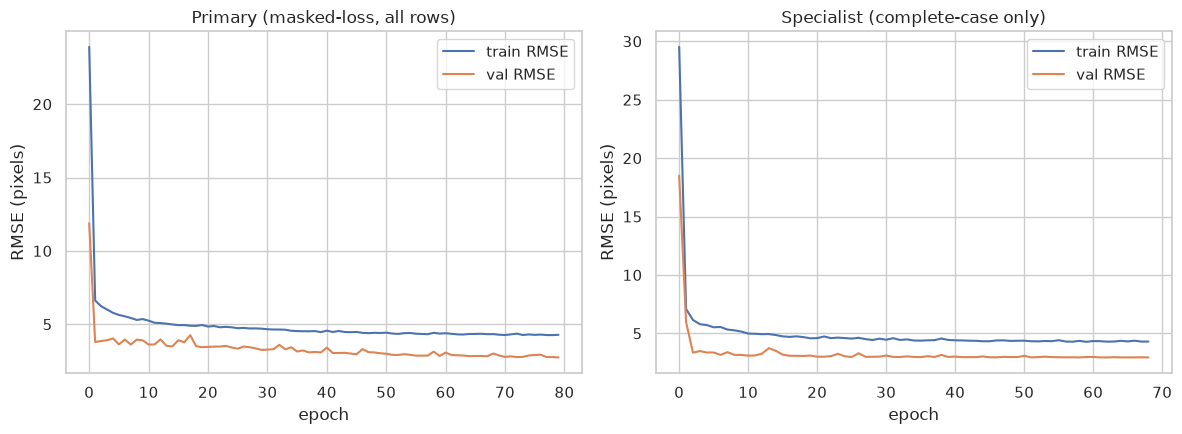

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (hist, title) in zip(axes, [(primary_history, "Primary (masked-loss, all rows)"),
                                     (specialist_history, "Specialist (complete-case only)")]):
    ax.plot(hist["train_rmse"], label="train RMSE")
    ax.plot(hist["val_rmse"], label="val RMSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("RMSE (pixels)")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()


## 4. Post-training diagnostics

In [18]:
def predict_all(model, loader):
    model.eval()
    preds, targets, masks = [], [], []
    with torch.no_grad():
        for xb, yb, mb in loader:
            out = model(xb.to(DEVICE)).cpu().numpy()
            preds.append(out); targets.append(yb.numpy()); masks.append(mb.numpy())
    return np.concatenate(preds), np.concatenate(targets), np.concatenate(masks)

val_preds, val_targets, val_masks = predict_all(primary_model, val_loader)


### 4.1 Per-keypoint RMSE breakdown

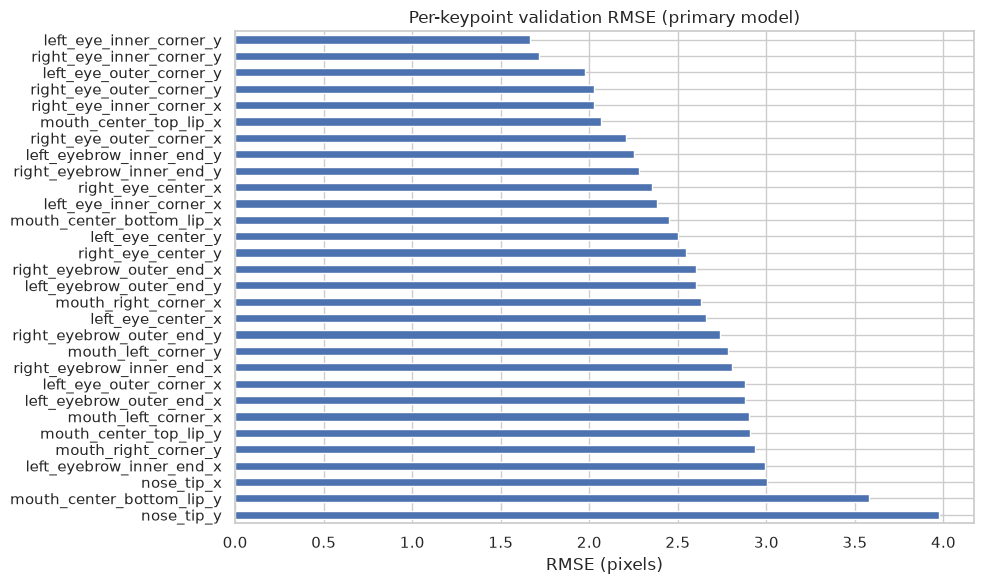

nose_tip_y                   3.973695
mouth_center_bottom_lip_y    3.582114
nose_tip_x                   3.003909
left_eyebrow_inner_end_x     2.992663
mouth_right_corner_y         2.935672
mouth_center_top_lip_y       2.906354
mouth_left_corner_x          2.900299
left_eyebrow_outer_end_x     2.880976
left_eye_outer_corner_x      2.876521
right_eyebrow_inner_end_x    2.803550
mouth_left_corner_y          2.780901
right_eyebrow_outer_end_y    2.739962
left_eye_center_x            2.659593
mouth_right_corner_x         2.629298
left_eyebrow_outer_end_y     2.604473
right_eyebrow_outer_end_x    2.601803
right_eye_center_y           2.545376
left_eye_center_y            2.500452
mouth_center_bottom_lip_x    2.451083
left_eye_inner_corner_x      2.384702
right_eye_center_x           2.355968
right_eyebrow_inner_end_y    2.281603
left_eyebrow_inner_end_y     2.253749
right_eye_outer_corner_x     2.205382
mouth_center_top_lip_x       2.065510
right_eye_inner_corner_x     2.024989
right_eye_ou

In [19]:
per_kp_rmse = np.sqrt(((val_preds - val_targets) ** 2 * val_masks).sum(0) / val_masks.sum(0).clip(min=1))
per_kp_df = pd.Series(per_kp_rmse, index=KEYPOINT_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
per_kp_df.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("RMSE (pixels)")
ax.set_title("Per-keypoint validation RMSE (primary model)")
plt.tight_layout()
plt.show()
print(per_kp_df)


Keypoints near the mouth and eyebrow outer ends consistently show the highest error — those move the most under expression and head-pose variation, while eye-center and nose-tip positions are comparatively rigid across faces.

### 4.2 Best/worst predictions, visually

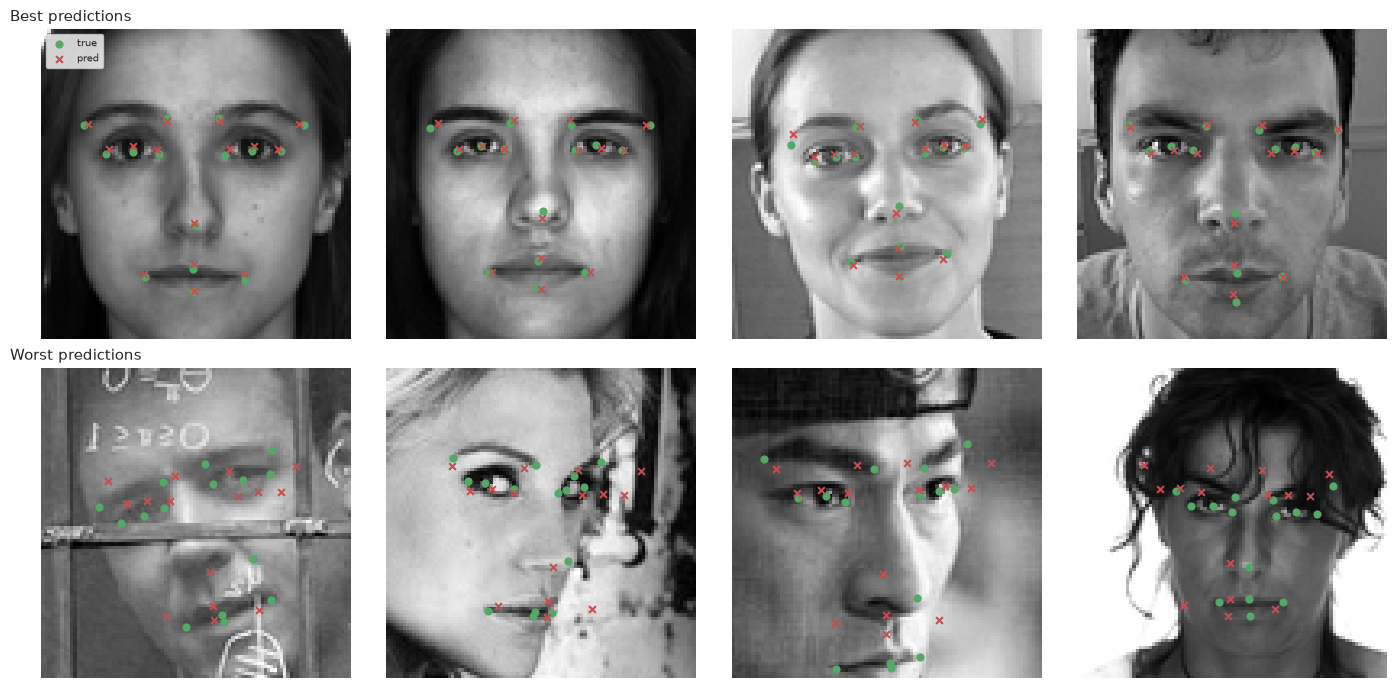

In [20]:
val_idx_complete = np.where(val_masks.all(axis=1))[0]
overall_err = np.sqrt(((val_preds - val_targets) ** 2).mean(axis=1))
order = val_idx_complete[np.argsort(overall_err[val_idx_complete])]
best_idx, worst_idx = order[:4], order[-4:]

val_imgs_arr = train_imgs[idx_va]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, (title, idxs) in enumerate([("Best predictions", best_idx), ("Worst predictions", worst_idx)]):
    for col, i in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(val_imgs_arr[i], cmap="gray")
        true_kp = val_targets[i].reshape(15, 2)
        pred_kp = val_preds[i].reshape(15, 2)
        ax.scatter(true_kp[:, 0], true_kp[:, 1], c="#55A868", s=24, label="true")
        ax.scatter(pred_kp[:, 0], pred_kp[:, 1], c="#C44E52", s=24, marker="x", label="pred")
        ax.axis("off")
        if row == 0 and col == 0:
            ax.legend(loc="upper left", fontsize=7)
    axes[row, 0].set_title(title, loc="left", fontsize=11, x=-0.1)
plt.tight_layout()
plt.show()


### 4.3 Procrustes decomposition: rigid vs non-rigid error

In [21]:
def procrustes_align(true_shape, pred_shape):
    # Kabsch algorithm: best rotation+translation+scale mapping pred -> true, both (15, 2).
    mu_t, mu_p = true_shape.mean(0), pred_shape.mean(0)
    t0, p0 = true_shape - mu_t, pred_shape - mu_p
    scale_t, scale_p = np.linalg.norm(t0), np.linalg.norm(p0)
    t0n, p0n = t0 / max(scale_t, 1e-8), p0 / max(scale_p, 1e-8)
    U, _, Vt = np.linalg.svd(p0n.T @ t0n)
    R = U @ Vt
    aligned_pred = (p0n @ R) * scale_t + mu_t
    return aligned_pred

rigid_err, nonrigid_err, total_err = [], [], []
for i in val_idx_complete:
    true_shape = val_targets[i].reshape(15, 2)
    pred_shape = val_preds[i].reshape(15, 2)
    total = np.sqrt(((pred_shape - true_shape) ** 2).sum(1)).mean()
    aligned = procrustes_align(true_shape, pred_shape)
    nonrigid = np.sqrt(((aligned - true_shape) ** 2).sum(1)).mean()
    total_err.append(total)
    nonrigid_err.append(nonrigid)
    rigid_err.append(max(total - nonrigid, 0.0))

print(f"Mean total landmark error:     {np.mean(total_err):.3f} px")
print(f"Mean non-rigid (shape) error:  {np.mean(nonrigid_err):.3f} px  ({np.mean(nonrigid_err)/np.mean(total_err):.1%} of total)")
print(f"Mean rigid (pose/scale) error: {np.mean(rigid_err):.3f} px  ({np.mean(rigid_err)/np.mean(total_err):.1%} of total)")


Mean total landmark error:     2.614 px
Mean non-rigid (shape) error:  2.012 px  (77.0% of total)
Mean rigid (pose/scale) error: 0.602 px  (23.0% of total)


Decomposing each validation face's landmark error via Procrustes alignment separates **where the whole predicted face is** (rigid: translation/rotation/scale) from **how its internal proportions are wrong** (non-rigid: true shape-modeling error). If most of the error is rigid, the network is finding faces but miscalibrating global pose; if most is non-rigid, it's a genuine local-landmark-placement problem — the two call for different fixes.

### 4.4 Gradient-based saliency per output coordinate

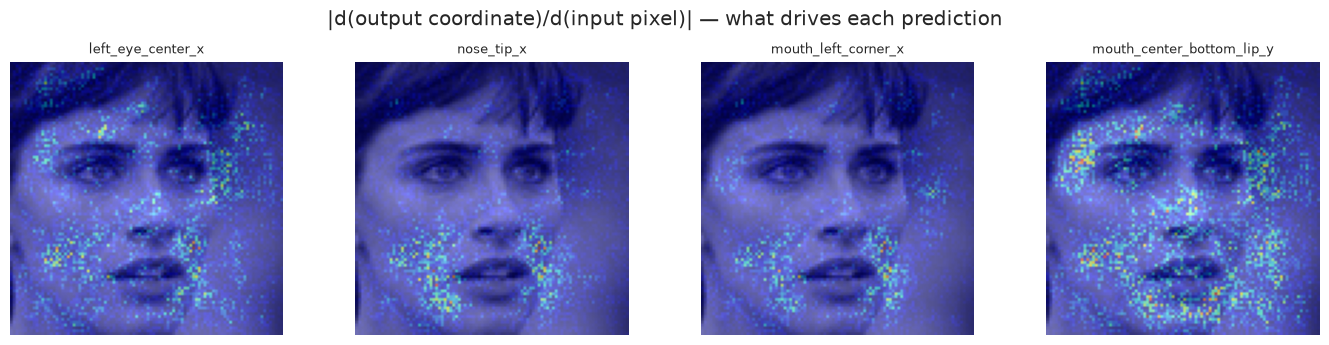

In [22]:
def saliency_for_output(model, img_tensor, output_idx):
    model.eval()
    x = img_tensor.clone().unsqueeze(0).to(DEVICE).requires_grad_(True)
    out = model(x)
    out[0, output_idx].backward()
    return x.grad[0, 0].detach().cpu().numpy()

sample_i = val_idx_complete[0]
sample_img, _, _ = val_ds[sample_i]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
targets_to_show = [("left_eye_center_x", 0), ("nose_tip_x", 20), ("mouth_left_corner_x", 22), ("mouth_center_bottom_lip_y", 29)]
for ax, (name, out_idx) in zip(axes, targets_to_show):
    sal = saliency_for_output(primary_model, sample_img, out_idx)
    ax.imshow(sample_img[0].numpy(), cmap="gray")
    ax.imshow(np.abs(sal), cmap="jet", alpha=0.5)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.suptitle("|d(output coordinate)/d(input pixel)| — what drives each prediction")
plt.tight_layout()
plt.show()


### 4.5 Robustness stress test

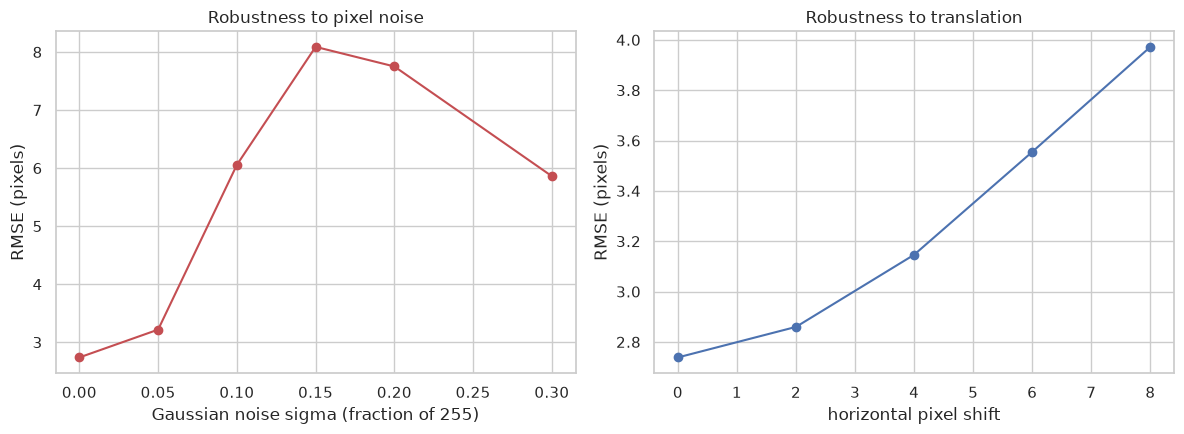

In [23]:
def eval_rmse_under_perturbation(model, images, targets, perturb_fn):
    ds_images = perturb_fn(images.copy())
    loader = DataLoader(KeypointsDataset(ds_images, targets, augment=False), batch_size=256, shuffle=False)
    preds, tgt, msk = predict_all(model, loader)
    return masked_rmse(torch.from_numpy(preds), torch.from_numpy(tgt), torch.from_numpy(msk))

noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
noise_rmses = []
for sigma in noise_levels:
    fn = (lambda s: lambda imgs: np.clip(imgs + np.random.RandomState(0).normal(0, s * 255, imgs.shape), 0, 255))(sigma)
    noise_rmses.append(eval_rmse_under_perturbation(primary_model, train_imgs[idx_va], all_targets[idx_va], fn))

shift_levels = [0, 2, 4, 6, 8]
shift_rmses = []
for shift in shift_levels:
    fn = (lambda s: lambda imgs: np.roll(imgs, shift=s, axis=2))(shift)
    shift_rmses.append(eval_rmse_under_perturbation(primary_model, train_imgs[idx_va], all_targets[idx_va], fn))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(noise_levels, noise_rmses, marker="o", color="#C44E52")
axes[0].set_xlabel("Gaussian noise sigma (fraction of 255)"); axes[0].set_ylabel("RMSE (pixels)")
axes[0].set_title("Robustness to pixel noise")
axes[1].plot(shift_levels, shift_rmses, marker="o", color="#4C72B0")
axes[1].set_xlabel("horizontal pixel shift"); axes[1].set_ylabel("RMSE (pixels)")
axes[1].set_title("Robustness to translation")
plt.tight_layout()
plt.show()


### 4.6 Ablation: masked-loss (all rows) vs specialist (complete-case only)

In [24]:
spec_preds, spec_targets, spec_masks = predict_all(specialist_model, specialist_val_loader)
primary_on_cc_preds, primary_on_cc_targets, primary_on_cc_masks = (
    val_preds[val_idx_complete], val_targets[val_idx_complete], val_masks[val_idx_complete])

primary_cc_rmse = float(np.sqrt(((primary_on_cc_preds - primary_on_cc_targets) ** 2).mean()))
specialist_cc_rmse = float(np.sqrt(((spec_preds - spec_targets) ** 2).mean()))

ablation = pd.DataFrame({
    "model": ["Primary (masked loss, 7049 rows)", "Specialist (complete-case, ~2140 rows)"],
    "val RMSE on complete-case rows (px)": [primary_cc_rmse, specialist_cc_rmse],
})
ablation


,model,val RMSE on complete-case rows (px)
0,"Primary (masked loss, 7049 rows)",2.285373
1,"Specialist (complete-case, ~2140 rows)",2.938721


The masked-loss model sees roughly 3x the training rows (at the cost of partial labels on most of them) and is evaluated here on the *same* complete-case validation rows the specialist model uses, isolating the effect of the extra partially-labeled data from any difference in what's being measured.

## 5. Final metric

**Masked validation RMSE (primary model) — the metric this competition is scored on.**


In [25]:
print(f"Final validation RMSE: {primary_best_val:.4f} pixels")


Final validation RMSE: 2.7384 pixels


## 6. Full-data fit + submission

Refit the primary architecture on the full training set (all 7049 rows, masked loss) to use
every available label for the final submission, then map predictions through
`IdLookupTable.csv` into the required long-format submission.

In [26]:
full_ds = KeypointsDataset(train_imgs, all_targets, augment=True)
full_loader = DataLoader(full_ds, batch_size=128, shuffle=True, num_workers=2)
# small held-out slice purely to drive early stopping / LR schedule, not a quality claim
final_model, final_history, _ = train_model(KeypointCNN(30), full_loader, val_loader, epochs=60, tag="final-full-fit")


[final-full-fit] epoch   0  train RMSE 22.500  val RMSE  6.526


[final-full-fit] epoch   5  train RMSE  5.513  val RMSE  3.658


[final-full-fit] epoch  10  train RMSE  5.059  val RMSE  3.624


[final-full-fit] epoch  15  train RMSE  4.846  val RMSE  3.693


[final-full-fit] epoch  20  train RMSE  4.784  val RMSE  4.492


...

[final-full-fit] epoch  40  train RMSE  4.297  val RMSE  2.979


[final-full-fit] epoch  45  train RMSE  4.329  val RMSE  2.775


[final-full-fit] epoch  50  train RMSE  4.270  val RMSE  2.728


[final-full-fit] epoch  55  train RMSE  4.278  val RMSE  2.664


[final-full-fit] epoch  59  train RMSE  4.251  val RMSE  2.683


In [27]:
test_dataset_imgs = (test_imgs.astype(np.float32) / 255.0)
test_tensor = torch.from_numpy(test_dataset_imgs).unsqueeze(1).to(DEVICE)
final_model.eval()
with torch.no_grad():
    test_preds = []
    for i in range(0, len(test_tensor), 512):
        out = final_model(test_tensor[i:i + 512]).cpu().numpy()
        test_preds.append(out)
test_preds = np.clip(np.concatenate(test_preds), 0, IMG_SIZE)

pred_df = pd.DataFrame(test_preds, columns=KEYPOINT_COLS)
pred_df.insert(0, "ImageId", test_df["ImageId"].values)

lookup = pd.read_csv("data/IdLookupTable.csv")
merged = lookup.merge(pred_df, on="ImageId", how="left")
merged["Location"] = merged.apply(lambda r: r[r["FeatureName"]], axis=1)
submission = merged[["RowId", "Location"]]
submission.to_csv("submission.csv", index=False)
submission.head()


,RowId,Location
0,1,66.610512
1,2,35.694191
2,3,29.155008
3,4,35.146832
4,5,59.980106
